In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow.keras.backend as K

In [2]:
df = pd.read_csv('Historical Data/daily_NVDA.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d-%m-%Y')
df = df.set_index('Timestamp')
df = df[['Close']]  # Use only the 'Close' price

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

In [3]:
def prepare_data(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = prepare_data(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [4]:
def mean_absolute_percentage_error(y_true, y_pred):
    return K.mean(K.abs((y_true - y_pred) / K.clip(K.abs(y_true), K.epsilon(), None))) * 100


In [5]:
model = Sequential()
model.add(LSTM(150, return_sequences=True, input_shape=(X_train.shape[1], 1), kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))
model.add(LSTM(150, return_sequences=False, kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(1))

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=[mean_absolute_percentage_error])

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
history = model.fit(X_train, y_train, epochs=30, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

Epoch 1/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - loss: 0.2249 - mean_absolute_percentage_error: 2973.0298 - val_loss: 0.1487 - val_mean_absolute_percentage_error: 50.2506
Epoch 2/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - loss: 0.1328 - mean_absolute_percentage_error: 28551.4863 - val_loss: 0.0883 - val_mean_absolute_percentage_error: 22.6794
Epoch 3/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - loss: 0.0791 - mean_absolute_percentage_error: 32356.3262 - val_loss: 0.0512 - val_mean_absolute_percentage_error: 36.0912
Epoch 4/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - loss: 0.0461 - mean_absolute_percentage_error: 33656.2812 - val_loss: 0.0290 - val_mean_absolute_percentage_error: 50.1567
Epoch 5/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - loss: 0.0266 - mean_absolute_percentage_error: 23431.7539 - val_loss: 0.0162 - val_mean_absolute_percentage_error: 41.6732
Epoch 6/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 27s 169ms/step - loss: 0.0156 - mean_absolute_percentage_erro

In [7]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step


In [8]:
mae = mean_absolute_error(y_test_actual, predictions)
rmse = sqrt(mean_squared_error(y_test_actual, predictions))
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")



Model Evaluation:
Mean Absolute Error (MAE): 7.14
Root Mean Squared Error (RMSE): 10.31
Mean Absolute Percentage Error (MAPE): 27.23%


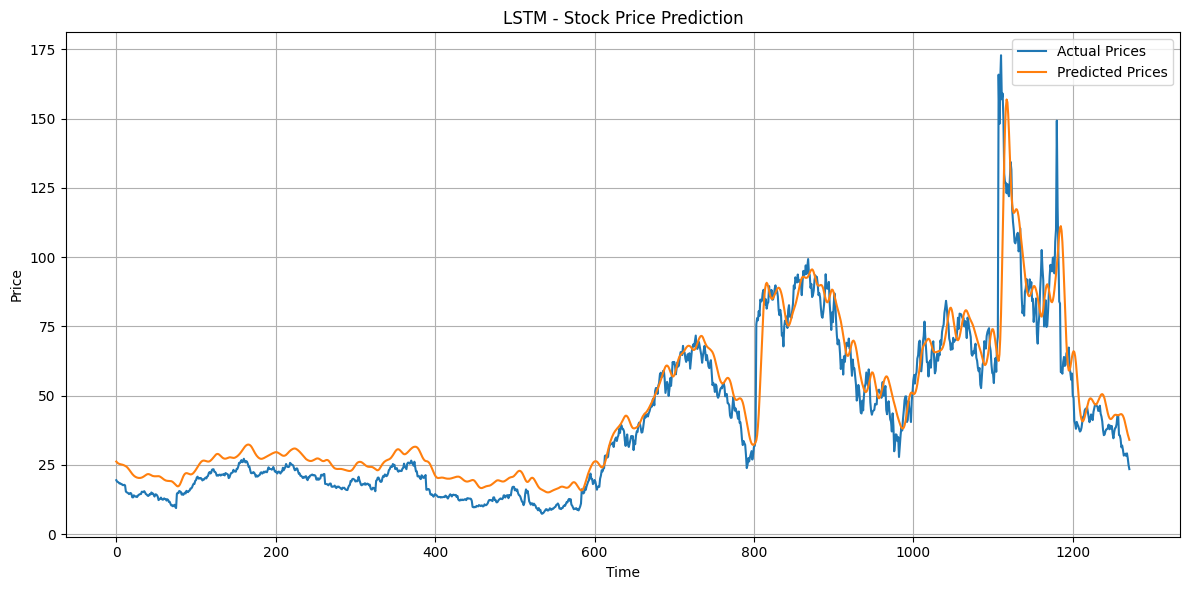

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices')
plt.title('LSTM - Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [10]:
from tensorflow.keras.models import save_model

# Save the trained model
model_save_path = 'nvda_stock_model.h5'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to nvda_stock_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━

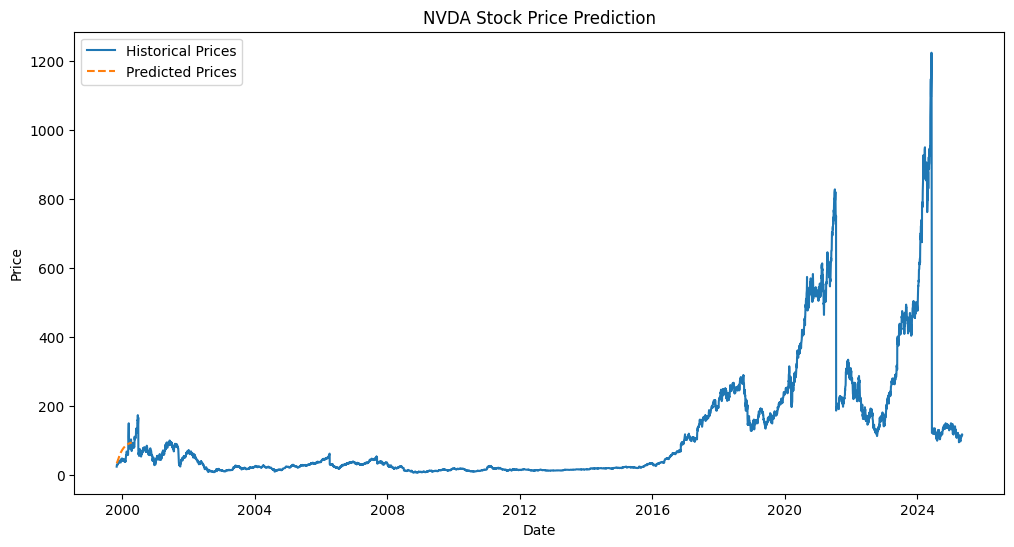

In [11]:
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('nvda_stock_model.h5')

# Prepare data for prediction
look_back = 60
future_days = 180  # 6 months
last_sequence = scaled_data[-look_back:]
predicted_prices = []
for _ in range(future_days):
    prediction = model.predict(np.reshape(last_sequence, (1, look_back, 1)))
    predicted_prices.append(prediction[0, 0])
    last_sequence = np.append(last_sequence[1:], prediction, axis=0)
predicted_prices = scaler.inverse_transform(np.array(predicted_prices).reshape(-1, 1))

# Plot the results
future_dates = pd.date_range(start=df.index[-1], periods=future_days + 1, freq='D')[1:]
future_dates = future_dates[::15]  # Select every 15th day
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Historical Prices')
plt.plot(future_dates, predicted_prices[::15], label='Predicted Prices', linestyle='--')
plt.title('NVDA Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━

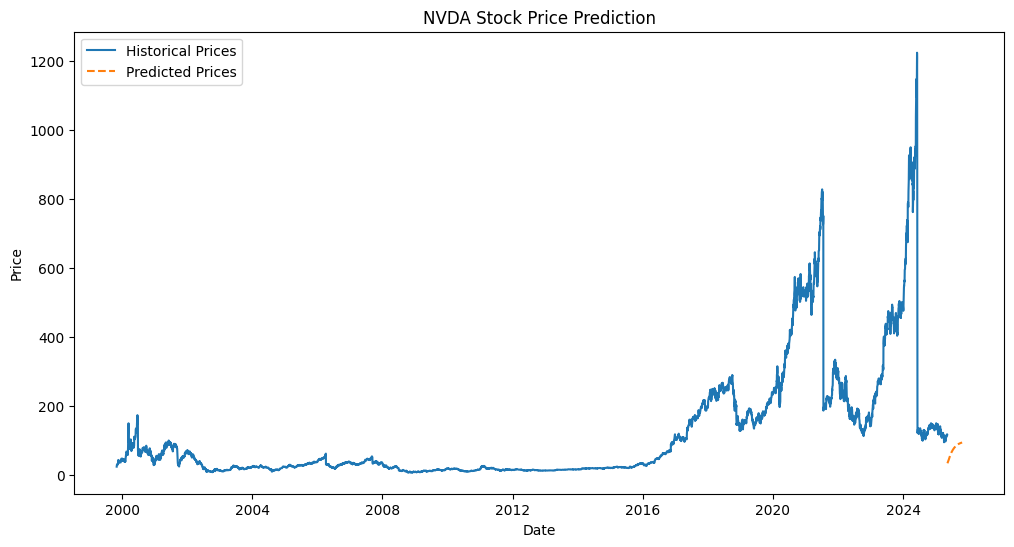

In [12]:
from datetime import datetime
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('nvda_stock_model.h5')

# Prepare data for prediction
look_back = 60
future_days = 180  # 6 months
last_sequence = scaled_data[-look_back:]
predicted_prices = []
for _ in range(future_days):
    prediction = model.predict(np.reshape(last_sequence, (1, look_back, 1)))
    predicted_prices.append(prediction[0, 0])
    last_sequence = np.append(last_sequence[1:], prediction, axis=0)
predicted_prices = scaler.inverse_transform(np.array(predicted_prices).reshape(-1, 1))

# Generate future dates from today's date
start_date = datetime(2025, 5, 11)
future_dates = pd.date_range(start=start_date, periods=future_days + 1, freq='D')[1:]
future_dates = future_dates[::15]  # Select every 15th day

# Display predicted values
for date, price in zip(future_dates, predicted_prices[::15]):
    print(f"Date: {date.strftime('%Y-%m-%d')}, Predicted Price: {price[0]:.2f}")

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Historical Prices')
plt.plot(future_dates, predicted_prices[::15], label='Predicted Prices', linestyle='--')
plt.title('NVDA Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()